In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup completed successfully!")

Matplotlib is building the font cache; this may take a moment.


Setup completed successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../Data/MiningProcess_Flotation_Plant_Database.csv")
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (737453, 24)

Columns:

Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='str')

Data Types:

date                            str
% Iron Feed                     str
% Silica Feed                   str
Starch Flow                     str
Amina Flow                      str
Ore Pulp Flow                   str
Ore Pulp pH                     str
Ore Pulp De

In [4]:
# Statistical summary
df.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453,...,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453
unique,4097,278,293,409317,319416,180189,131143,105805,43675,80442,...,86819,299573,331189,322315,309264,276051,301502,295667,38696,55569
top,2017-03-10 02:00:00,"64,03","6,26","2562,5","534,668","402,246","10,0591","1,75","299,927","255,322",...,"299,487","452,441","608,887","601,06","491,406","513,879","474,37","479,478","65,44","2,08"
freq,180,142560,142560,690,959,1735,1509,3214,13683,1487,...,3405,1013,817,989,733,709,746,905,16920,17100


In [5]:
target = "% Silica Concentrate"

print("Target Variable:", target)

Target Variable: % Silica Concentrate


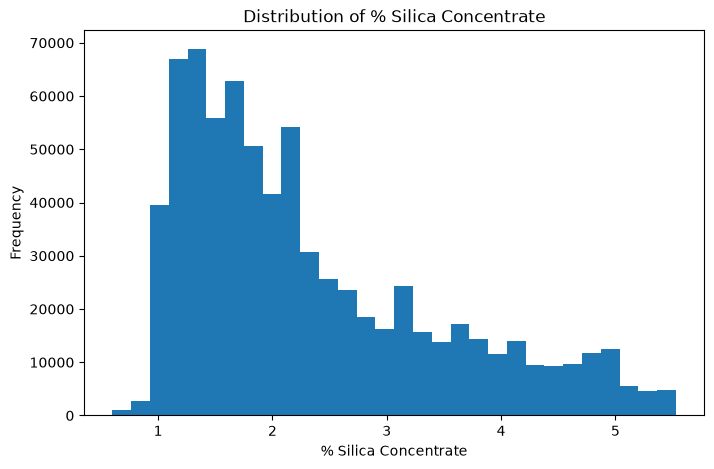

In [7]:
# Convert target column to numeric if needed
df["% Silica Concentrate"] = (
    df["% Silica Concentrate"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["% Silica Concentrate"] = pd.to_numeric(
    df["% Silica Concentrate"],
    errors="coerce"
)

plt.figure(figsize=(8,5))

plt.hist(df["% Silica Concentrate"].dropna(), bins=30)

plt.title("Distribution of % Silica Concentrate")
plt.xlabel("% Silica Concentrate")
plt.ylabel("Frequency")

plt.show()

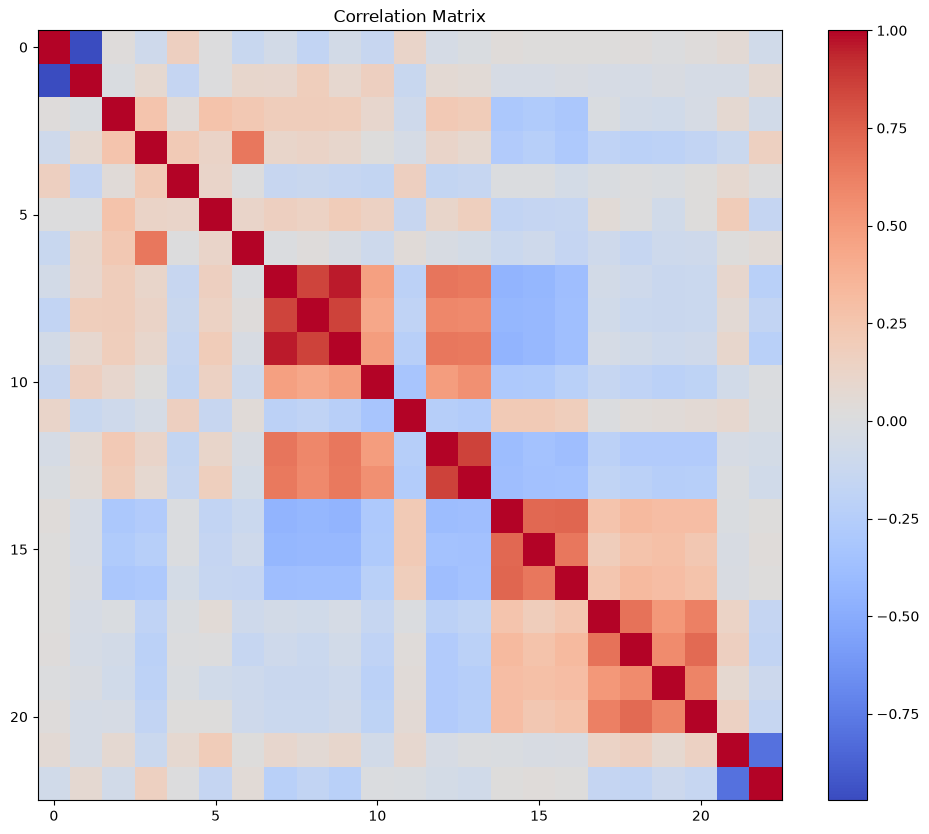

In [8]:
# Remove the date column
numeric_df = df.drop(columns=["date"])

# Convert all remaining columns to numeric
for col in numeric_df.columns:
    numeric_df[col] = (
        numeric_df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

corr = numeric_df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [9]:
# Features and Target
X = numeric_df.drop(columns=["% Silica Concentrate"])

y = numeric_df["% Silica Concentrate"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (737453, 22)
Target Shape: (737453,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (589962, 22)
Testing Data: (147491, 22)


In [11]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))
print("R2 Score:", r2_score(y_test, lr_predictions))

Linear Regression Results
MAE : 0.49205253163527285
RMSE: 0.6364332527098482
R2 Score: 0.6795062825960534


In [13]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [14]:
print("Decision Tree Results")

print("MAE :", mean_absolute_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R2 Score:", r2_score(y_test, dt_predictions))

Decision Tree Results
MAE : 0.2952963198349401
RMSE: 0.43046325926654816
R2 Score: 0.8533824445834634


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R2 Score:", r2_score(y_test, rf_predictions))

Random Forest Results
MAE : 0.010428269854413233
RMSE: 0.04712712724011069
R2 Score: 0.9982426602652931


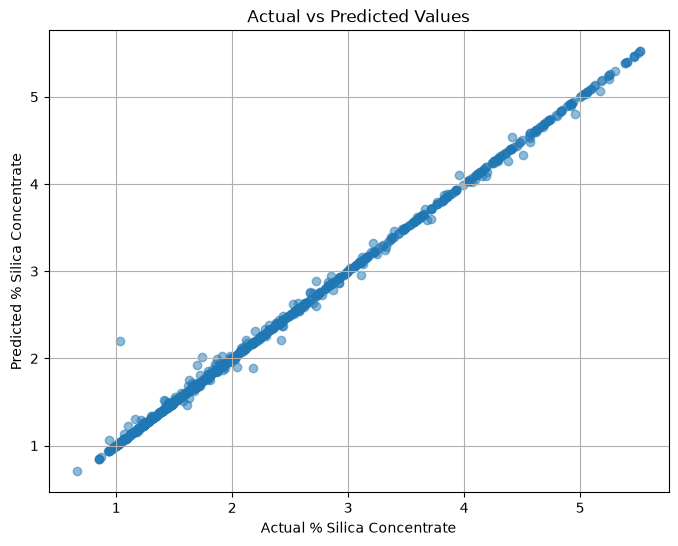

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test[:1000],
    rf_predictions[:1000],
    alpha=0.5
)

plt.xlabel("Actual % Silica Concentrate")
plt.ylabel("Predicted % Silica Concentrate")
plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.savefig("../Images/actual_vs_predicted.png")

plt.show()

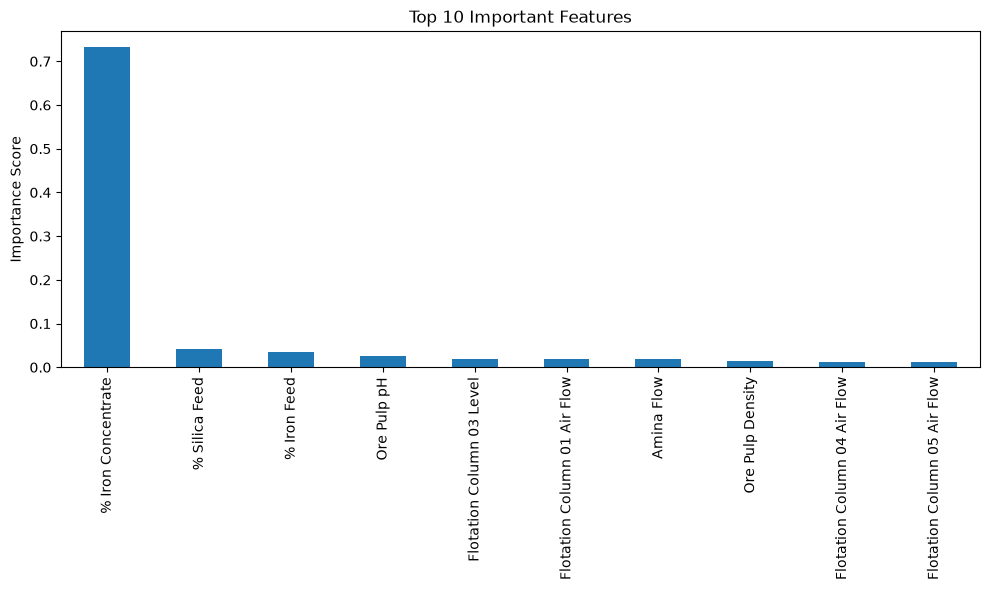

In [18]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.savefig("../Images/feature_importance.png")

plt.show()

In [19]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.679506,0.492053,0.636433
1,Decision Tree,0.853382,0.295296,0.430463
2,Random Forest,0.998243,0.010428,0.047127


In [20]:
pip install joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import joblib

joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/random_forest_model.pkl'